# Agricultural Productivity & Yield Analysis in India
### Capstone Project 5: Exploratory Data Analysis & Statistical Modeling
**Author:** Trivedi Dharmik  
**Date:** 18-Jul-2026  
**Source Dataset:** GOI Agricultural Statistics (Ministry of Agriculture & Farmers Welfare, via data.gov.in)  

---

## 1. Environment Setup & Data Loading
We import necessary libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and load the crop production database and state-zone reference mapping.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'Arial']

# Load datasets
df = pd.read_csv('crop_production_cleaned.csv')
df_ref = pd.read_csv('state_zone_ref.csv')

print(f"Cleaned Crop Data shape: {df.shape}")
print(f"Reference Data shape: {df_ref.shape}")
df.head()

Cleaned Crop Data shape: (10000, 10)
Reference Data shape: (32, 2)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Yield_Index,is_outlier
0,Puducherry,Puducherry District D,2015,Summer,Jowar,37918.10,30437.56,0.802718,0.795354,0
1,Karnataka,Karnataka District E,2015,Rabi,Onion,619.98,5026.27,8.107149,0.712603,0
2,Kerala,Kerala District B,2015,Kharif,Sugarcane,9168.84,196896.95,21.474576,0.349838,0
3,Telangana,Telangana District D,2015,Summer,Arhar/Tur,15323.37,8358.79,0.545493,0.683551,0
4,West Bengal,West Bengal District D,2015,Rabi,Onion,49242.18,447034.21,9.078278,0.797963,0


## 2. Data Loading & Overview
Let's review the basic info, statistics, and check for missing values to verify our cleaning process.

In [ ]:
# Dataset information
print("=== Dataset Info ===")
df.info()

# Missing values
print("\n=== Missing Values Summary ===")
print(df.isnull().sum())

# Descriptive statistics
print("\n=== Descriptive Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State_Name     10000 non-null  object 
 1   District_Name  10000 non-null  object 
 2   Crop_Year      10000 non-null  int64  
 3   Season         10000 non-null  object 
 4   Crop           10000 non-null  object 
 5   Area           10000 non-null  float64
 6   Production     10000 non-null  float64
 7   Yield          10000 non-null  float64
 8   Yield_Index    10000 non-null  float64
 9   is_outlier     10000 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 781.4+ KB

=== Missing Values Summary ===
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
Yield            0
Yield_Index      0
is_outlier       0
dtype: int64

=== Descriptive Statistics ===


,Crop_Year,Area,Production,Yield,Yield_Index,is_outlier
count,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,2005.518900,25000.278115,1.284511e+05,5.151955,1.000000,0.012300
std,5.219901,24764.894889,5.308345e+05,16.400848,0.371681,0.110227
min,1997.000000,100.290000,6.210000e+00,0.009999,0.000879,0.000000
25%,2001.000000,7244.737500,7.055828e+03,0.659025,0.754521,0.000000
50%,2006.000000,17618.645000,1.952490e+04,1.067793,0.963847,0.000000
75%,2010.000000,34539.205000,5.284707e+04,1.957751,1.208312,0.000000
max,2015.000000,228104.410000,2.214162e+07,612.942138,9.985321,1.000000


## 3. Univariate Analysis
We analyze the distribution of individual variables like cultivated Area, raw Yield, and the normalized Yield Index.

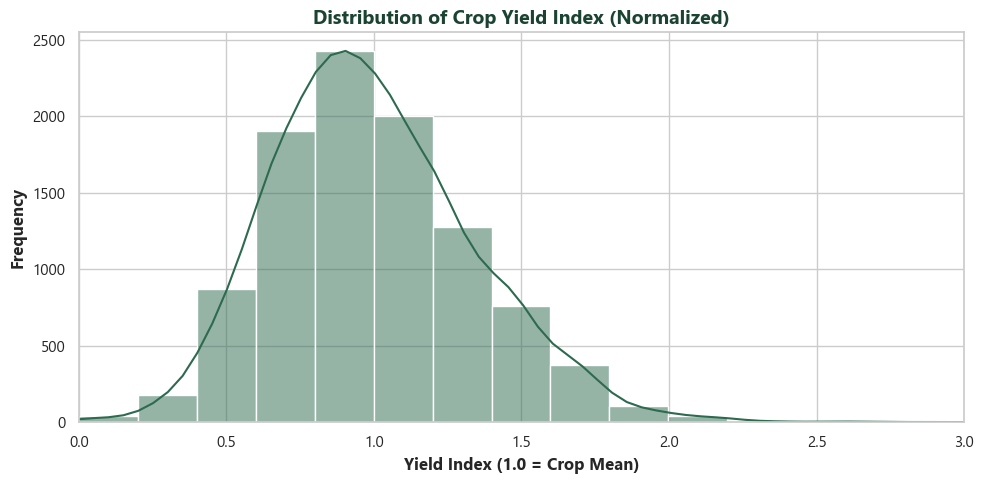

In [ ]:
# Plot distribution of Yield Index
plt.figure(figsize=(10, 5))
sns.histplot(df['Yield_Index'], bins=50, kde=True, color='#2D6A4F')
plt.title('Distribution of Crop Yield Index (Normalized)', fontsize=14, fontweight='bold', color='#1B4332')
plt.xlabel('Yield Index (1.0 = Crop Mean)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.xlim(0, 3)
plt.tight_layout()
plt.show()

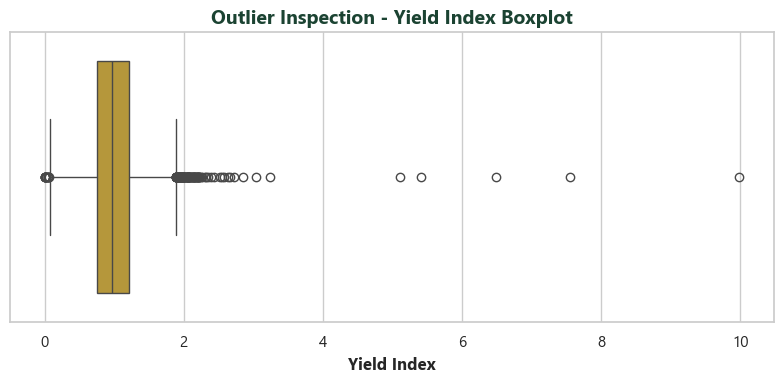

In [ ]:
# Boxplot of Yield Index to inspect outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Yield_Index'], color='#C9A227')
plt.title('Outlier Inspection - Yield Index Boxplot', fontsize=14, fontweight='bold', color='#1B4332')
plt.xlabel('Yield Index', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Bivariate & Multivariate Analysis
Let's look at the correlation structure and the relationship between cultivated area and crop yield.

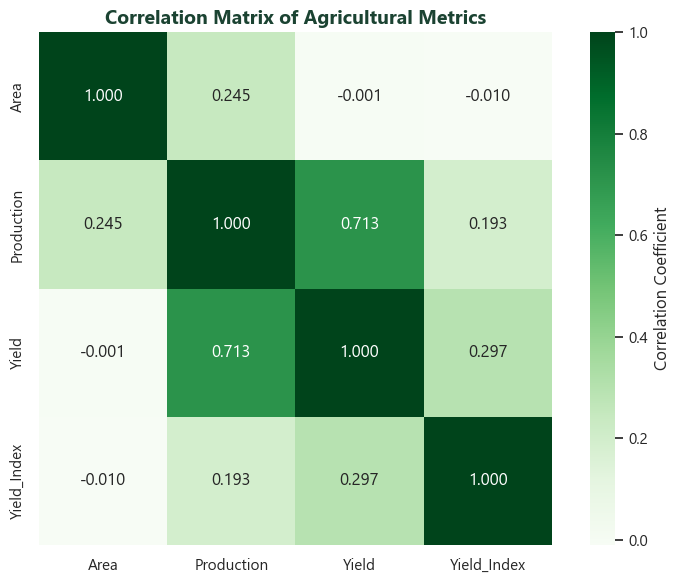

In [ ]:
# Correlation Heatmap between numeric features
plt.figure(figsize=(8, 6))
corr = df[['Area', 'Production', 'Yield', 'Yield_Index']].corr()
sns.heatmap(corr, annot=True, cmap='Greens', fmt='.3f', square=True, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Agricultural Metrics', fontsize=14, fontweight='bold', color='#1B4332')
plt.tight_layout()
plt.show()

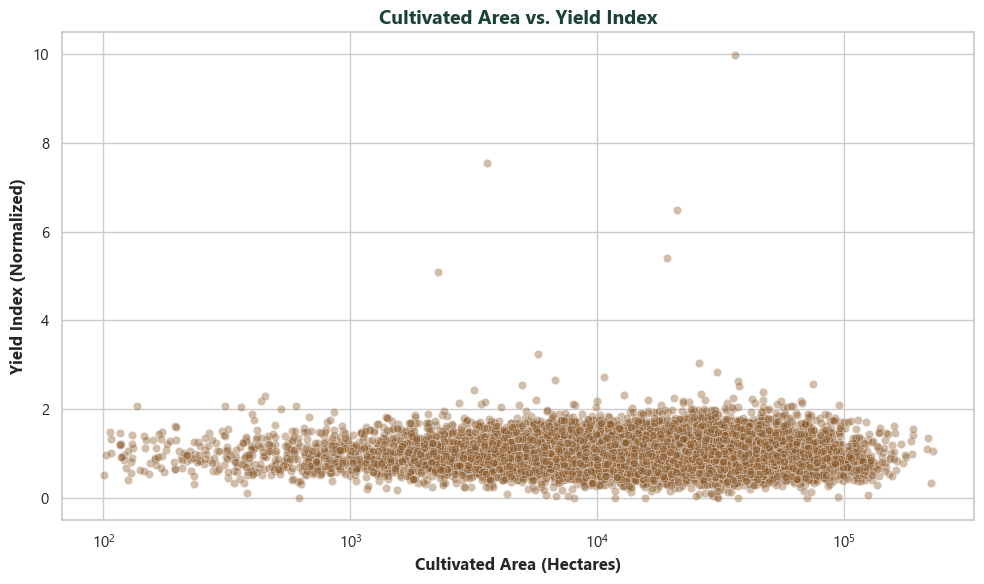

Correlation between Area and Yield Index: -0.0103


In [ ]:
# Scatter plot: Area vs Yield Index to check correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area', y='Yield_Index', alpha=0.4, data=df, color='#8B5A2B')
plt.title('Cultivated Area vs. Yield Index', fontsize=14, fontweight='bold', color='#1B4332')
plt.xlabel('Cultivated Area (Hectares)', fontweight='bold')
plt.ylabel('Yield Index (Normalized)', fontweight='bold')
plt.xscale('log')
plt.tight_layout()
plt.show()

print(f"Correlation between Area and Yield Index: {df['Area'].corr(df['Yield_Index']):.4f}")

## 5. Geographic & Zone Performance Analysis
We join the crop data with the state-zone reference table to analyze zone-level productivity.

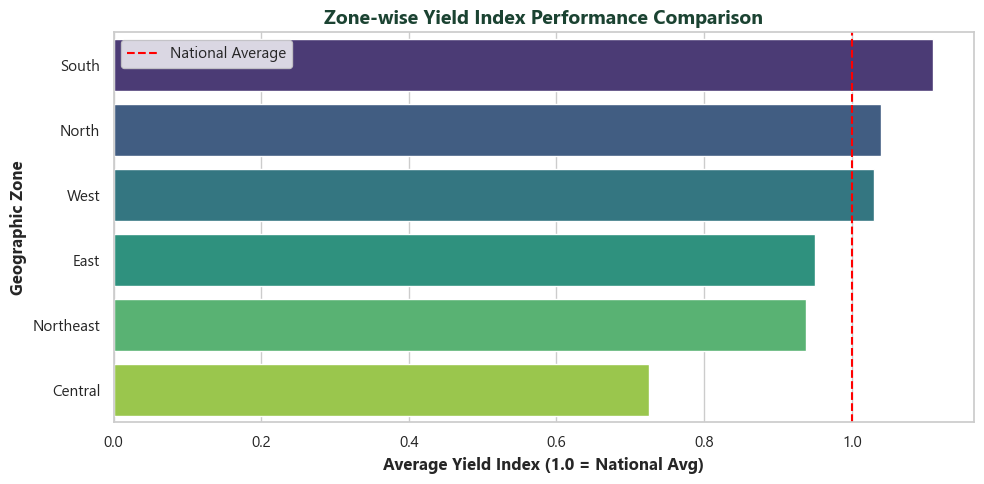

,Zone,Yield_Index
0,South,1.110044
1,North,1.038996
2,West,1.029446
3,East,0.950550
4,Northeast,0.938449
5,Central,0.724955


In [ ]:
# Merge with state reference
df_merged = df.merge(df_ref, on='State_Name', how='inner')

# Zone-wise yields
zone_perf = df_merged.groupby('Zone')['Yield_Index'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Yield_Index', y='Zone', data=zone_perf, palette='viridis', hue='Zone', legend=False)
plt.title('Zone-wise Yield Index Performance Comparison', fontsize=14, fontweight='bold', color='#1B4332')
plt.xlabel('Average Yield Index (1.0 = National Avg)', fontweight='bold')
plt.ylabel('Geographic Zone', fontweight='bold')
plt.axvline(1.0, color='red', linestyle='--', label='National Average')
plt.legend()
plt.tight_layout()
plt.show()

zone_perf

## 6. Detailed State Performance
Let's rank individual states by their average Yield Index.

In [ ]:
state_perf = df_merged.groupby(['State_Name', 'Zone'])['Yield_Index'].agg(['mean', 'count']).reset_index()
state_perf = state_perf.rename(columns={'mean': 'Avg_Yield_Index', 'count': 'Total_Records'})
state_perf = state_perf.sort_values(by='Avg_Yield_Index', ascending=False)

# Top 5 states
print("=== Top 5 States by Yield Index ===")
print(state_perf.head(5))

# Bottom 5 states
print("\n=== Bottom 5 States by Yield Index ===")
print(state_perf.tail(5))

=== Top 5 States by Yield Index ===
        State_Name   Zone  Avg_Yield_Index  Total_Records
23          Punjab  North         1.483308            319
22      Puducherry  South         1.437870            326
8          Gujarat   West         1.239476            293
1   Andhra Pradesh  South         1.222687            299
26      Tamil Nadu  South         1.187333            338

=== Bottom 5 States by Yield Index ===
           State_Name     Zone  Avg_Yield_Index  Total_Records
10   Himachal Pradesh    North         0.780507            306
12          Jharkhand     East         0.750789            323
21             Odisha     East         0.719739            285
11  Jammu and Kashmir    North         0.714623            311
5        Chhattisgarh  Central         0.650978            304
